# Sutdent Name : 
## Resigeration Number: 123
## Project: Alzhimer Classification

# Step one
### Importing the necessary libraries

In [3]:
import os 
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.resnet import ResNet50


from keras.callbacks import EarlyStopping,ModelCheckpoint,Callback
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tqdm import tqdm
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import to_categorical
from keras import optimizers

#from keras.callbacks import Callback,ModelCheckpoint
#from keras.models import Sequential,load_model
#from keras.layers import Dense, Dropout
#from keras.wrappers.scikit_learn import KerasClassifier
import keras.backend as K
print("All library loaded")

All library loaded


# Step Two
### Load the Dataset

In [9]:
images = []
labels = []
for subfolder in tqdm(os.listdir('/kaggle/input/alzheimer-mri-4-classes-dataset')):
    subfolder_path = os.path.join('/kaggle/input/alzheimer-mri-4-classes-dataset', subfolder)
    for folder in os.listdir(subfolder_path):
        subfolder_path2=os.path.join(subfolder_path,folder)
        for image_filename in os.listdir(subfolder_path2):
            image_path = os.path.join(subfolder_path2, image_filename)
            images.append(image_path)
            labels.append(folder)
df = pd.DataFrame({'image': images, 'label': labels})
df

100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


,image,label
0,/kaggle/input/alzheimer-mri-4-classes-dataset/...,ModerateDemented
1,/kaggle/input/alzheimer-mri-4-classes-dataset/...,ModerateDemented
2,/kaggle/input/alzheimer-mri-4-classes-dataset/...,ModerateDemented
3,/kaggle/input/alzheimer-mri-4-classes-dataset/...,ModerateDemented
4,/kaggle/input/alzheimer-mri-4-classes-dataset/...,ModerateDemented
...,...,...
6395,/kaggle/input/alzheimer-mri-4-classes-dataset/...,MildDemented
6396,/kaggle/input/alzheimer-mri-4-classes-dataset/...,MildDemented
6397,/kaggle/input/alzheimer-mri-4-classes-dataset/...,MildDemented
6398,/kaggle/input/alzheimer-mri-4-classes-dataset/...,MildDemented


# Step Three
### Explore the Dataset

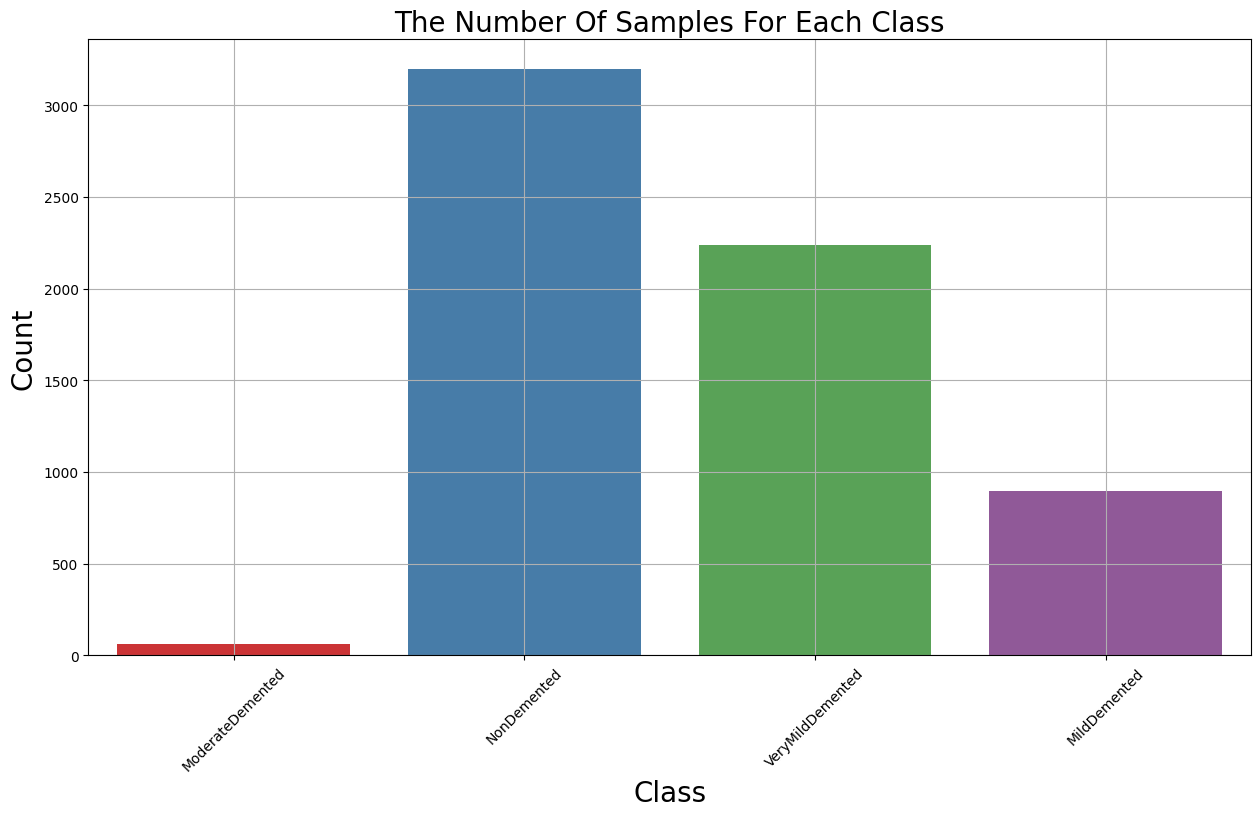

In [10]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x=df.label,palette='Set1')
ax.set_xlabel("Class",fontsize=20)
ax.set_ylabel("Count",fontsize=20)
plt.title('The Number Of Samples For Each Class',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

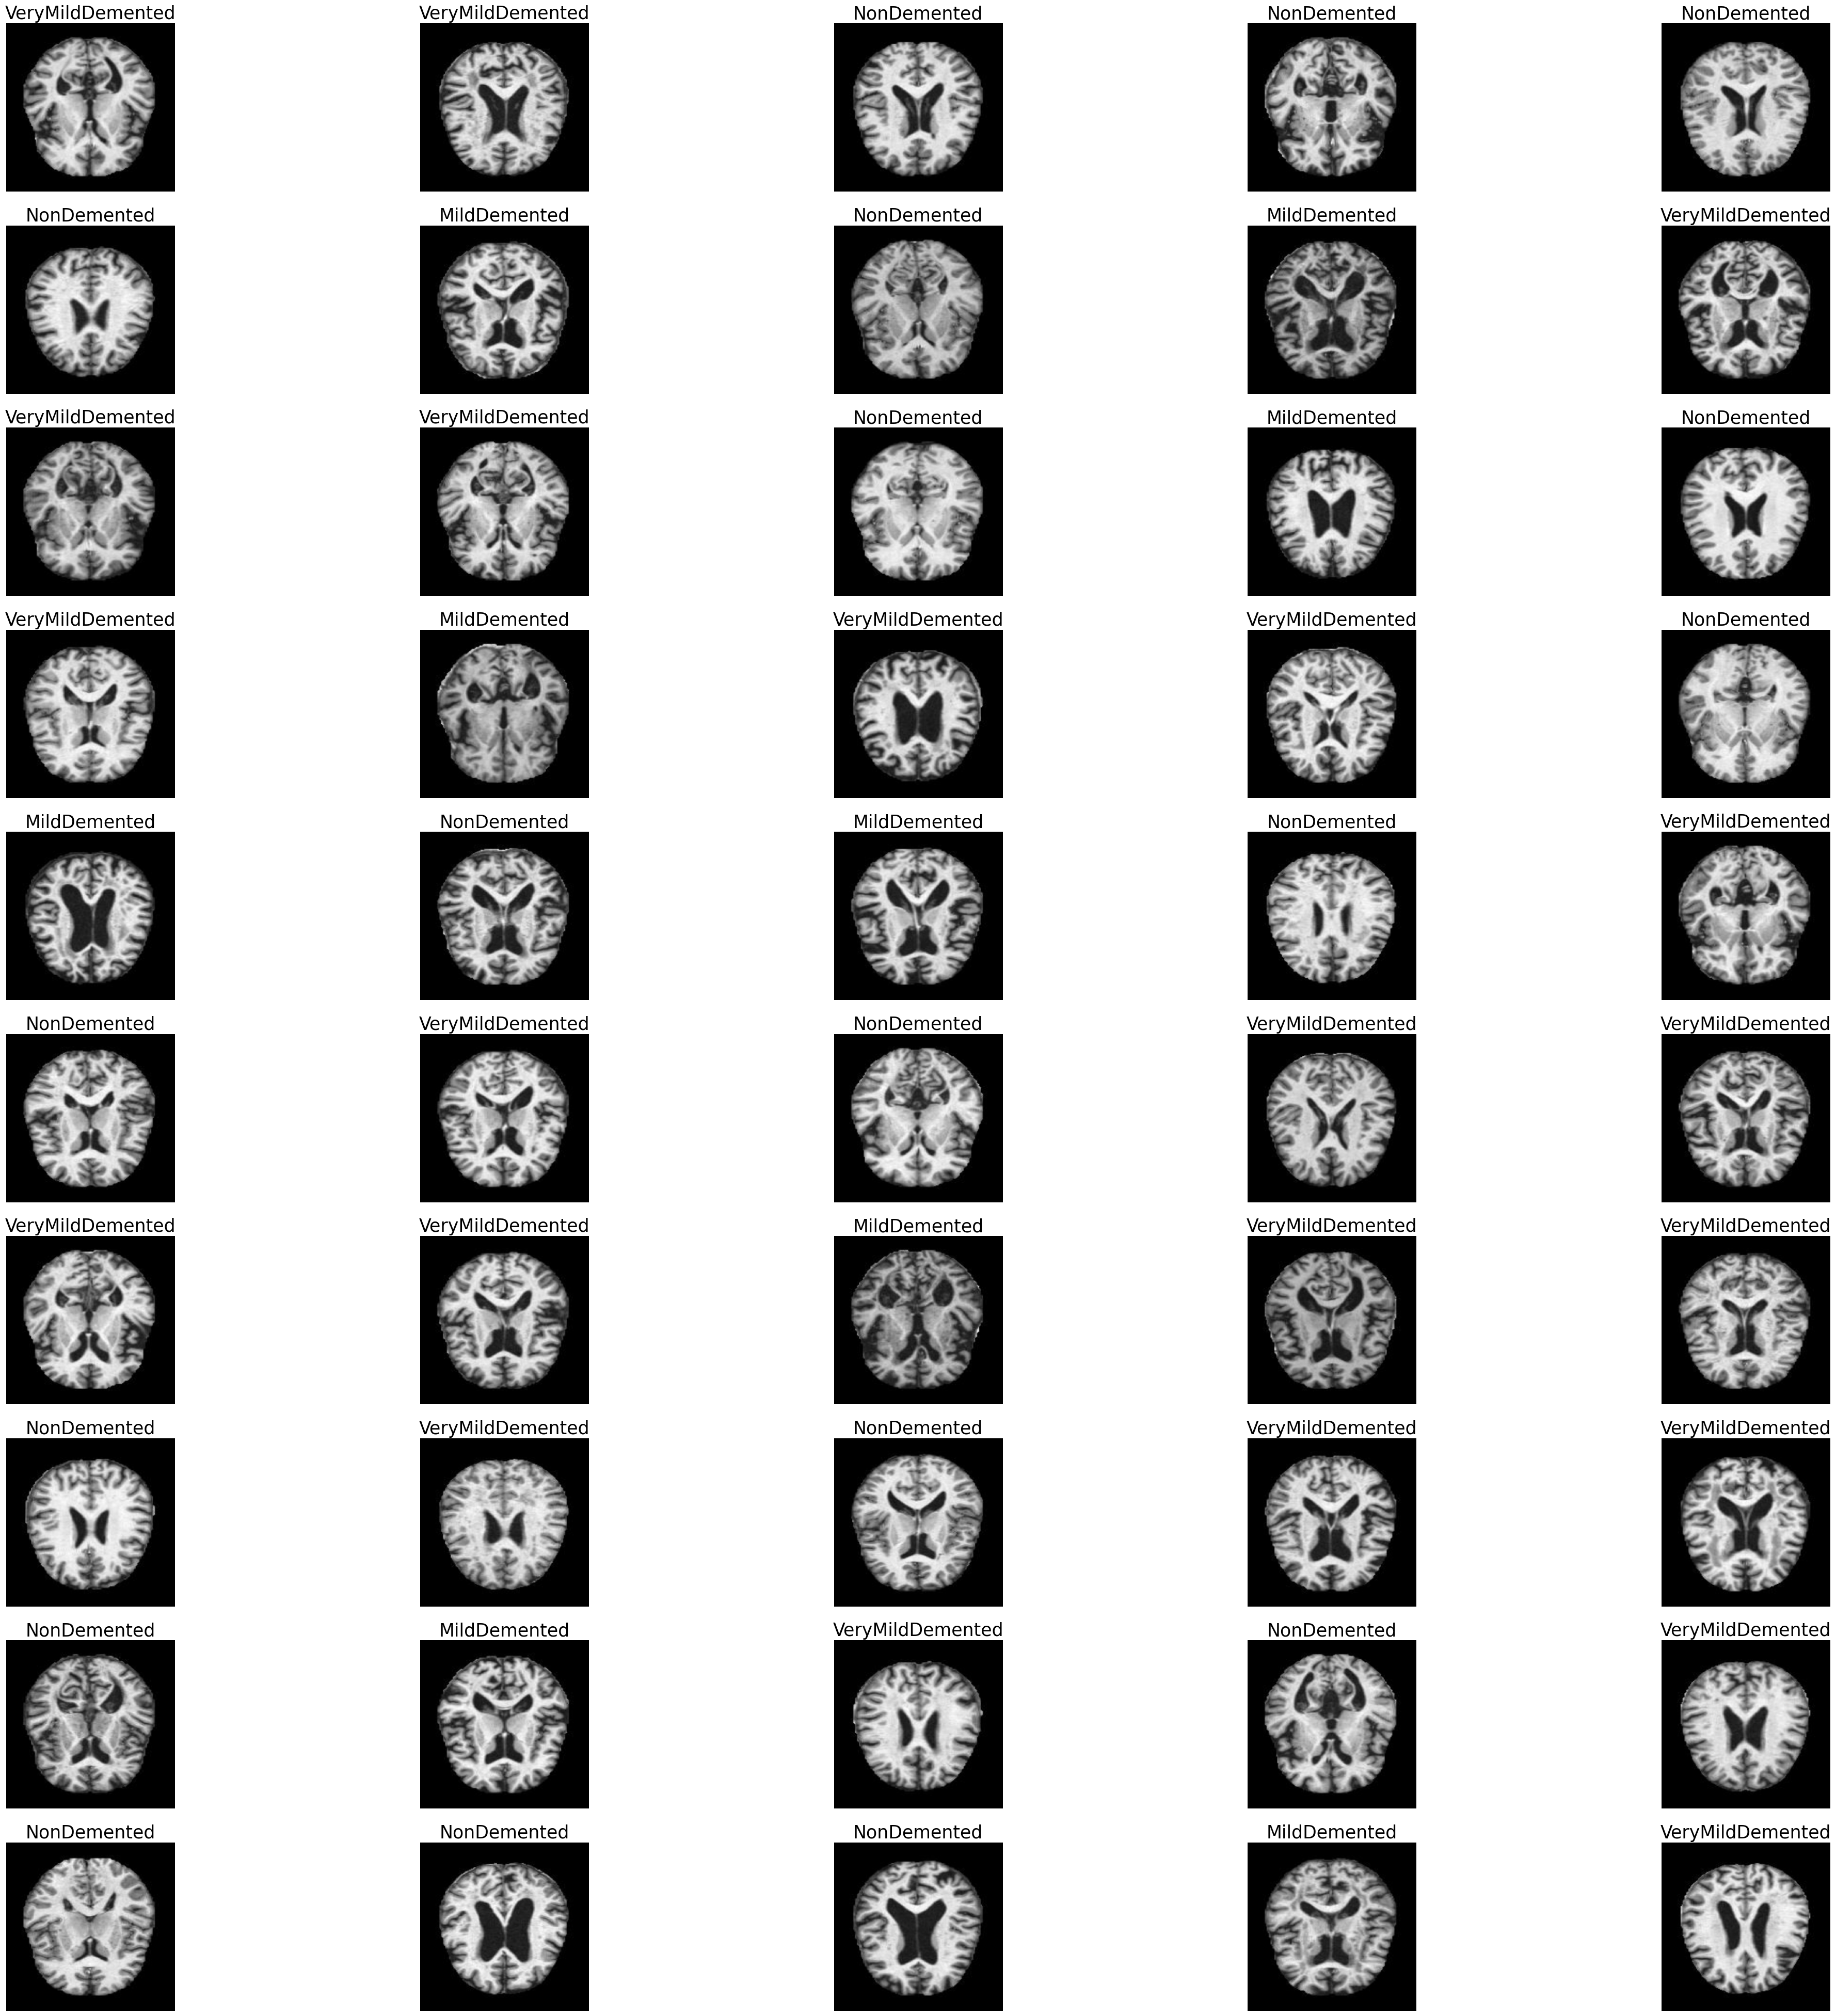

In [11]:
plt.figure(figsize=(50,50))
for n,i in enumerate(np.random.randint(0,len(df),50)):
    plt.subplot(10,5,n+1)
    img=cv2.imread(df.image[i])
    img=cv2.resize(img,(224,224))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.title(df.label[i],fontsize=25)

In [12]:
Size=(176,176)
work_dr = ImageDataGenerator(
    rescale = 1./255
)
train_data_gen = work_dr.flow_from_dataframe(df,x_col='image',y_col='label', target_size=Size, batch_size=6500, shuffle=False)

Found 6400 validated image filenames belonging to 4 classes.


In [13]:
for i in range(len(train_data_gen)):
    train_data, train_labels = train_data_gen[i]

In [14]:
class_num=np.sort(['0','1','2','3','4'])
class_num

array(['0', '1', '2', '3', '4'], dtype='<U1')

# Step Four
# Data Preprocessing

## Performing over-sampling on dataset because our dataset is imbalance 

In [15]:
sm = SMOTE(random_state=42)
train_data, train_labels = sm.fit_resample(train_data.reshape(-1, 176 * 176 * 3), train_labels)
train_data = train_data.reshape(-1, 176,176, 3)
print(train_data.shape, train_labels.shape)

(12800, 176, 176, 3) (12800, 4)


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


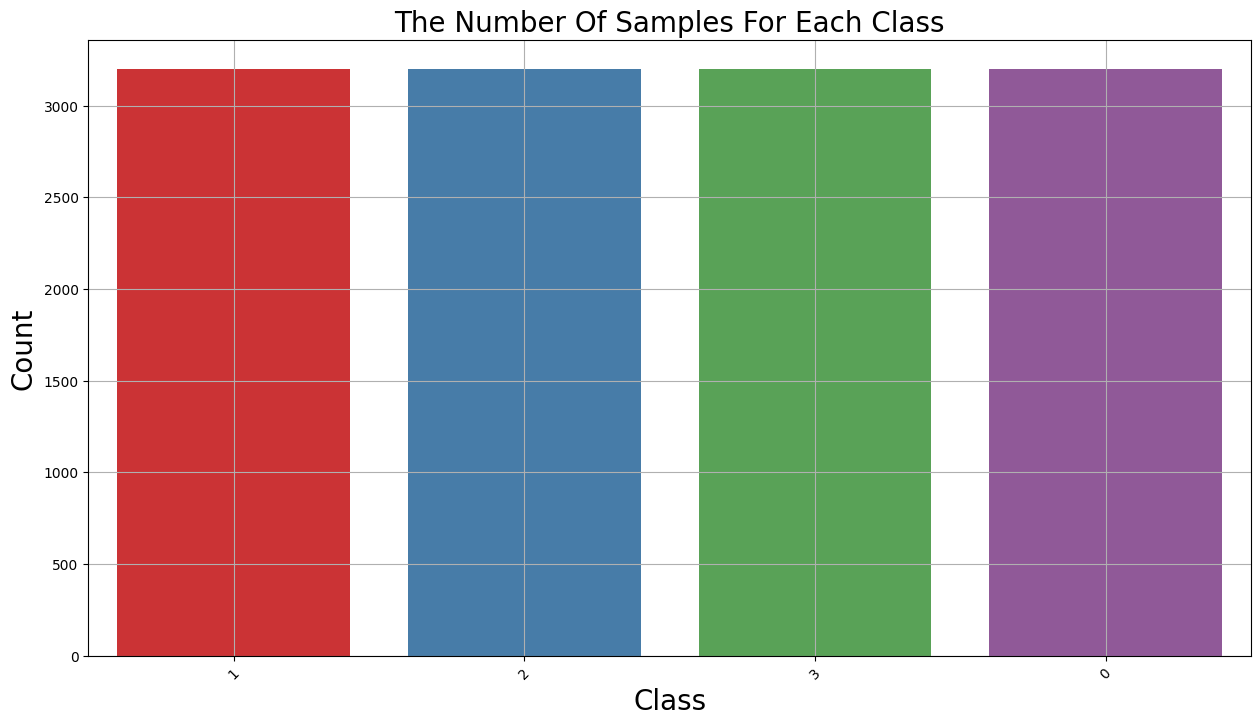

In [16]:
labels=[class_num[i] for i in np.argmax(train_labels,axis=1) ]
plt.figure(figsize=(15,8))
ax = sns.countplot(x=labels,palette='Set1')
ax.set_xlabel("Class",fontsize=20)
ax.set_ylabel("Count",fontsize=20)
plt.title('The Number Of Samples For Each Class',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## Select an image from the oversampled data for checking the resutl apply on our dataset

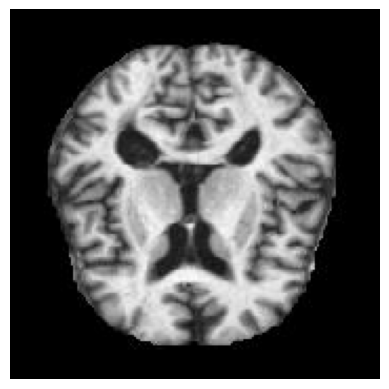

In [17]:
# Choose an index to select an image from the oversampled data for checking the result apply on our dataset
index = 42  

# Read the image data from train_data
image = train_data[index]

# Plot the image using matplotlib
plt.imshow(image)
plt.axis('off')
plt.show()


## let’s first explore the RGB channels of our original image

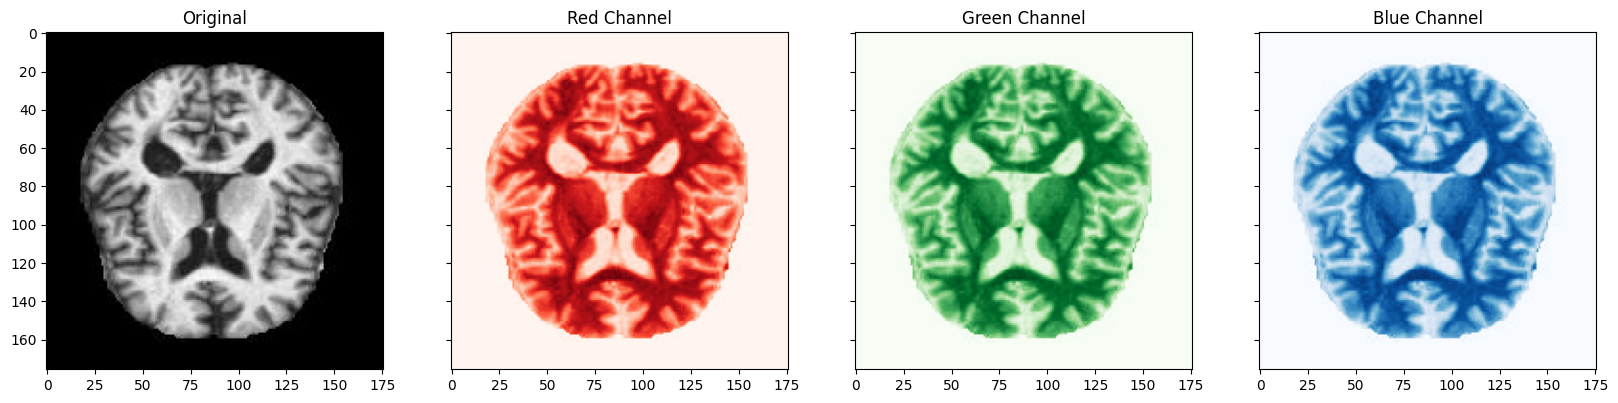

In [18]:
import matplotlib.pyplot as plt

# Plotting the original image and the RGB channels
fig, (im1, im2, im3, im4) = plt.subplots(1, 4, sharey=True)
fig.set_figwidth(20) 

im1.imshow(image)  # Original image
im2.imshow(image[:, :, 0], cmap='Reds')  # Red channel
im3.imshow(image[:, :, 1], cmap='Greens')  # Green channel
im4.imshow(image[:, :, 2], cmap='Blues')  # Blue channel

im1.set_title('Original')
im2.set_title('Red Channel')
im3.set_title('Green Channel')
im4.set_title('Blue Channel')

plt.show()


# Grayscale conversion¶

## But our images already in Grayscale


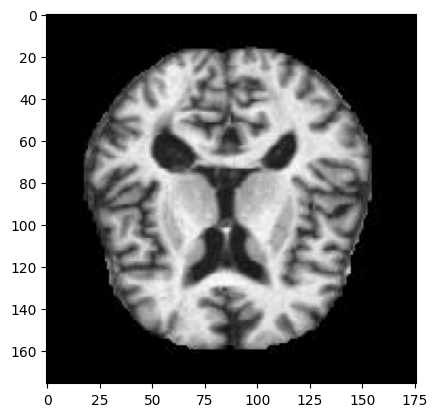

In [19]:
import skimage
gray_image = skimage.color.rgb2gray(image)
plt.imshow(gray_image, cmap = 'gray')

# Data augmentation
### Data augmentation means making small changes to existing data to make it more varied, without having to gather new data.

## Shifting
### This is the process of shifting image pixels horizontally or vertically.

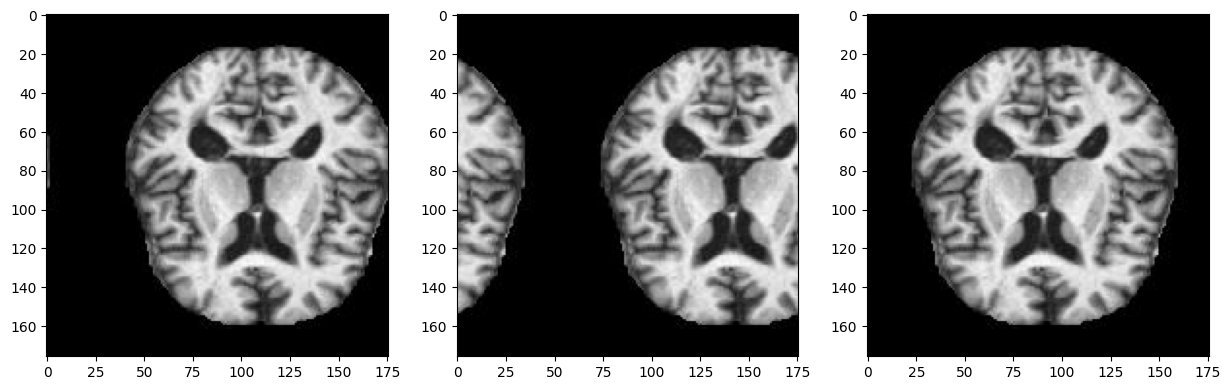

In [20]:

# Define a function for random width shifting
def random_width_shift(image, shift_range):
    shifted_image = np.roll(image, shift=np.random.randint(shift_range[0], shift_range[1]), axis=1)
    return shifted_image

# Create a list to hold augmented images
augmented_images = []

# Generate augmented images
for _ in range(3):
    augmented_image = random_width_shift(image, [-200, 200])
    augmented_images.append(augmented_image)

# Plot the augmented images
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
for ax, augmented_image in zip(axes, augmented_images):
    ax.imshow(cv2.cvtColor(augmented_image, cv2.COLOR_BGR2RGB))
plt.show()

## Flipping
### This reverses the rows or columns of pixels in either vertical or horizontal cases, respectively.

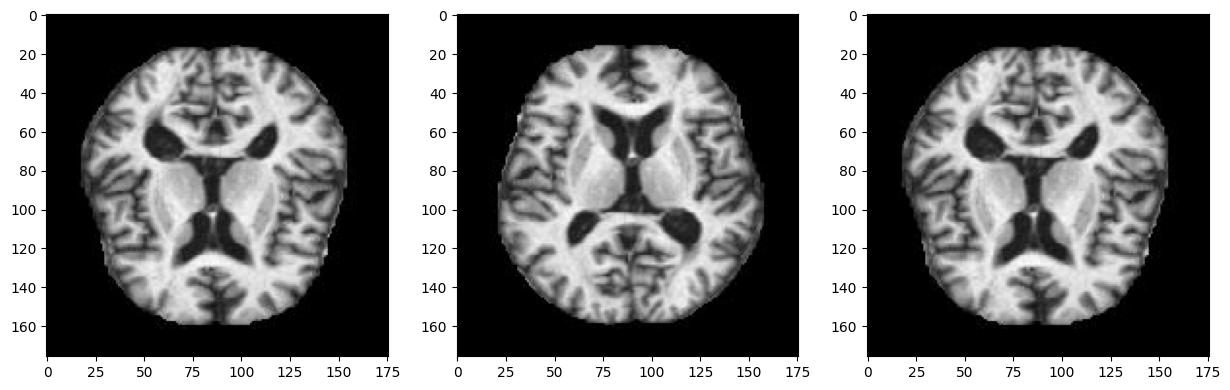

In [21]:
# Define a function for random flipping augmentation
def random_flip_image(image):
    flip_horizontal = np.random.choice([True, False])
    flip_vertical = np.random.choice([True, False])
    if flip_horizontal:
        image = cv2.flip(image, 1)
    if flip_vertical:
        image = cv2.flip(image, 0)
    return image

# Convert image to RGB for plotting
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create a list to hold augmented images
augmented_images = []

# Generate augmented images
for _ in range(3):
    augmented_image = random_flip_image(image_rgb)
    augmented_images.append(augmented_image)

# Plot the augmented images
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
for ax, augmented_image in zip(axes, augmented_images):
    ax.imshow(augmented_image)
plt.show()

## Rotation
### This process involves rotating an image by a specified degree.

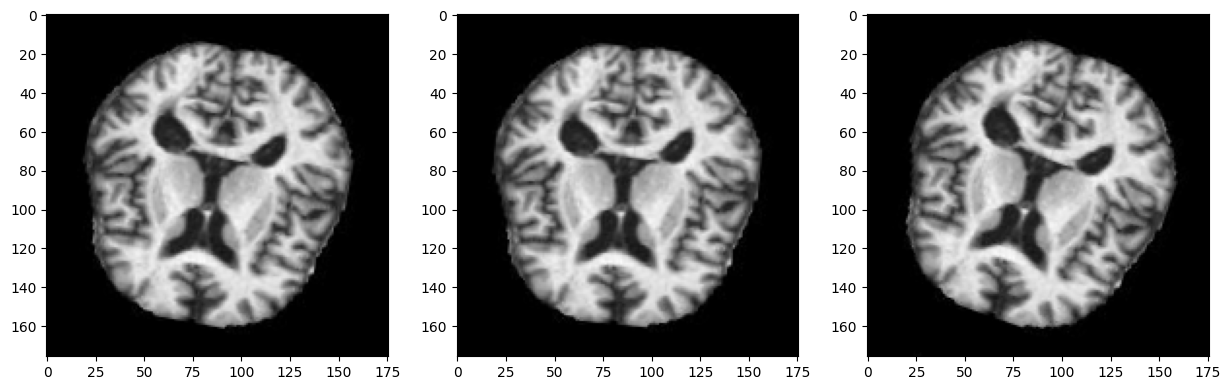

In [22]:
# Define a function for rotation augmentation
def rotate_image(image, angle_range):
    angle = np.random.uniform(angle_range[0], angle_range[1])
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    return rotated_image

# Convert image to RGB for plotting
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create a list to hold augmented images
augmented_images = []

# Generate augmented images
for _ in range(3):
    augmented_image = rotate_image(image_rgb, [-20, 20])  # Rotation range: -20 to 20 degrees
    augmented_images.append(augmented_image)

# Plot the augmented images
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
for ax, augmented_image in zip(axes, augmented_images):
    ax.imshow(augmented_image)
plt.show()

# Step Five

## Making the Variables for training data


In [23]:
X_train, X_test1, y_train, y_test1 = train_test_split(train_data,train_labels, test_size=0.3, random_state=42,shuffle=True,stratify=train_labels)
X_val, X_test, y_val, y_test = train_test_split(X_test1,y_test1, test_size=0.5, random_state=42,shuffle=True,stratify=y_test1)
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('X_val shape is ' , X_val.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)
print('y_val shape is ' , y_val.shape)

X_train shape is  (8960, 176, 176, 3)
X_test shape is  (1920, 176, 176, 3)
X_val shape is  (1920, 176, 176, 3)
y_train shape is  (8960, 4)
y_test shape is  (1920, 4)
y_val shape is  (1920, 4)


## Building the Model 

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input

class_num = 4
input_shape = (176, 176, 3)
base_model = ResNet50(include_top=False, weights="imagenet", input_tensor=Input(shape=input_shape))

for layer in base_model.layers:
    layer.trainable = False

# Building Model
model = tf.keras.Sequential()
model.add(base_model)
model.add(Dropout(0.5))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(64, kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(64, kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(64, kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32, kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32, kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(class_num, activation='softmax'))
model.build((None,) + input_shape)
ResNet = model
ResNet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73728)          │       294,912 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,718,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │             

 Total params: 28,613,892 (109.15 MB)

 Trainable params: 4,878,212 (18.61 MB)

 Non-trainable params: 23,735,680 (90.54 MB)

## Train the Model 

In [25]:
checkpoint_cb =ModelCheckpoint("ResNet.keras", save_best_only=True)
early_stopping_cb =EarlyStopping(patience=10, restore_best_weights=True)
ResNet.compile(optimizer ='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist = ResNet.fit(X_train,y_train, epochs=30, validation_data=(X_val,y_val), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/30
  1/280 ━━━━━━━━━━━━━━━━━━━━ 2:20:51 30s/step - accuracy: 0.3750 - loss: 1.5016

I0000 00:00:1729941031.584240     214 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1729941031.651770     214 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3008 - loss: 1.4720

W0000 00:00:1729941054.899850     214 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


280/280 ━━━━━━━━━━━━━━━━━━━━ 59s 101ms/step - accuracy: 0.3010 - loss: 1.4717 - val_accuracy: 0.4495 - val_loss: 1.1562
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.4446 - loss: 1.1173 - val_accuracy: 0.5010 - val_loss: 0.8947
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.4808 - loss: 0.9907 - val_accuracy: 0.4984 - val_loss: 0.8539
Epoch 4/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.4877 - loss: 0.9635 - val_accuracy: 0.5047 - val_loss: 0.8446
Epoch 5/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.4894 - loss: 0.9246 - val_accuracy: 0.5005 - val_loss: 0.8329
Epoch 6/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.5315 - loss: 0.8916 - val_accuracy: 0.5714 - val_loss: 0.8073
Epoch 7/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.5493 - loss: 0.8797 - val_accuracy: 0.6495 - val_loss: 0.7407
Epoch 8/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.5954 - loss: 0.8423 - val_accura

In [26]:
hist_=pd.DataFrame(hist.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.337054,1.372615,0.449479,1.156223
1,0.458705,1.080850,0.501042,0.894736
2,0.478013,0.977987,0.498437,0.853873
3,0.497321,0.946326,0.504687,0.844576
4,0.494643,0.925830,0.500521,0.832893
5,0.528125,0.906101,0.571354,0.807298
6,0.556808,0.873279,0.649479,0.740738
7,0.593862,0.841589,0.670313,0.699537
8,0.617076,0.806741,0.694792,0.667277
9,0.627455,0.790346,0.715625,0.650548


## Accuracy score

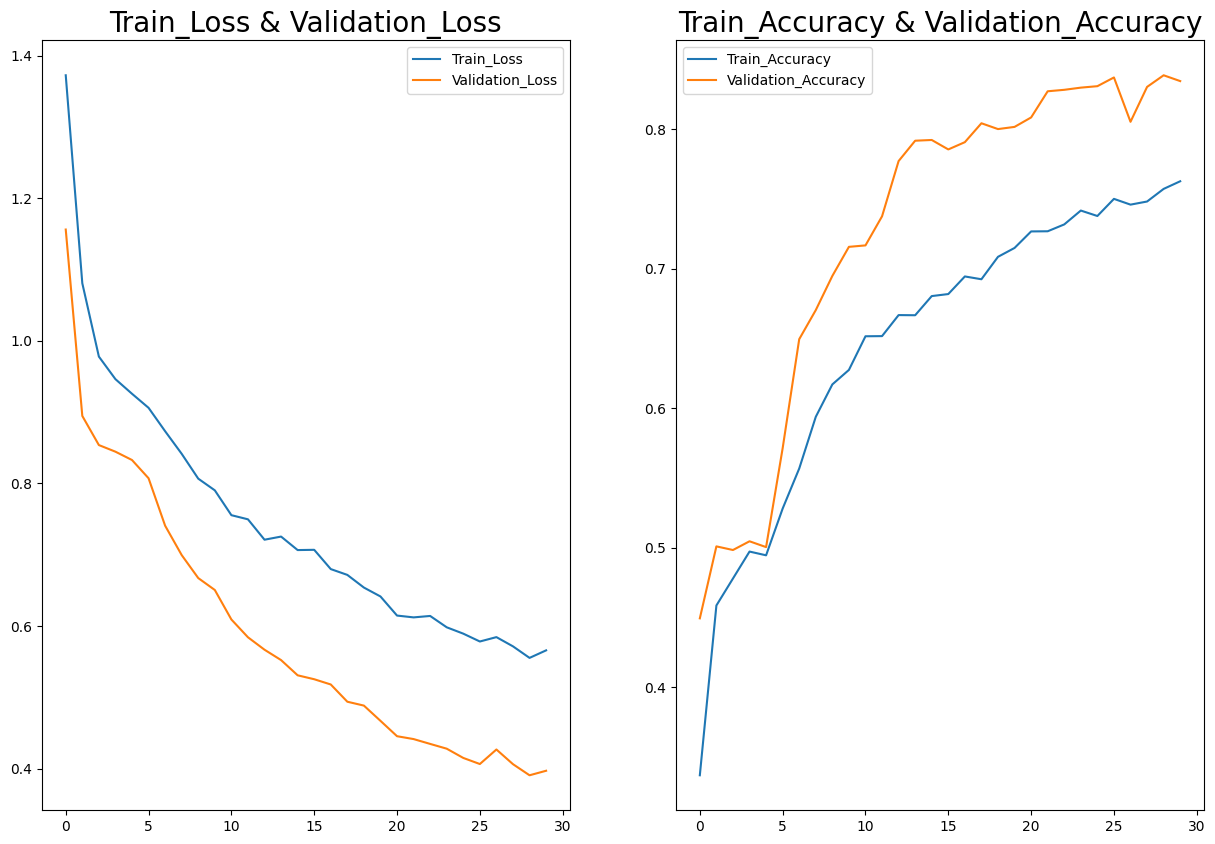

In [27]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()
plt.show()

In [28]:
score, acc= ResNet.evaluate(X_test,y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8733 - loss: 0.3704
Test Loss = 0.3766311705112457
Test Accuracy = 0.8645833134651184


In [29]:
predictions = ResNet.predict(X_test)
y_pred = np.argmax(predictions,axis=1)
y_test_ = np.argmax(y_test,axis=1)
df = pd.DataFrame({'Actual': y_test_, 'Prediction': y_pred})
df

 4/60 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step

W0000 00:00:1729941725.424706     215 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step


,Actual,Prediction
0,1,1
1,1,1
2,0,0
3,2,2
4,2,2
...,...,...
1915,2,2
1916,0,0
1917,2,2
1918,3,3


array([[469,   0,   0,  11],
       [  0, 480,   0,   0],
       [  8,   0, 294, 178],
       [ 24,   0,  39, 417]])

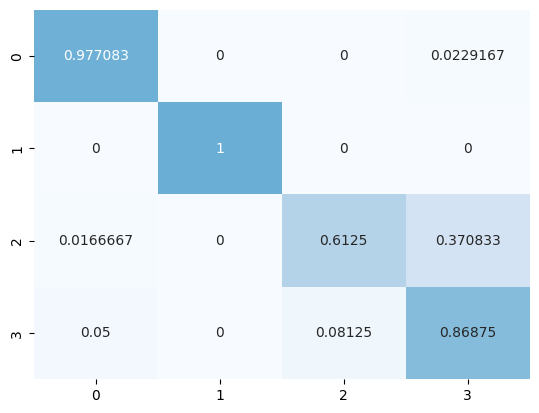

In [30]:
CM = confusion_matrix(y_test_,y_pred)
CM_percent = CM.astype('float') / CM.sum(axis=1)[:, np.newaxis]
sns.heatmap(CM_percent,fmt='g',center = True,cbar=False,annot=True,cmap='Blues')
CM

## Classification Report

In [31]:
ClassificationReport = classification_report(y_test_,y_pred)
print('Classification Report is : ', ClassificationReport )

Classification Report is :                precision    recall  f1-score   support

           0       0.94      0.98      0.96       480
           1       1.00      1.00      1.00       480
           2       0.88      0.61      0.72       480
           3       0.69      0.87      0.77       480

    accuracy                           0.86      1920
   macro avg       0.88      0.86      0.86      1920
weighted avg       0.88      0.86      0.86      1920



In [33]:
model.save('alzheimer_cnn_model.h5')

ValueError: Unable to synchronously create dataset (name already exists)